In [ ]:
# 🧠 Module X — Lesson Title


# The Mathematical foundation

The reader must be already aare until now that all AI algorithms in general are founded on some mathematical theory behind, Calculus, Algebra, Probability... . take leastsquare for examples, the algorithm solves an optimization problem trying to reduce the sum of resiuals, the all known SVM as-well, tries to solve another optimization problem, to find the best separation line between clusters, but what about Generative-AI ?


# I. Foundation : 
think about it this way, we want a model to generate some animals for example, so an accepted-said model must at least satisfy the following criterions : 
* succeed to catch at least dozens of animals (dogs, cats, horses... ). 
* and for each category, must have some kind of diversity, so somehow if we can specefy to the model that we want a cat, we hope to get different animals given the same command.

Naturally a mere function fails to model this, since by definition of a function, it can't have multiple outputs for a given input, hence it will fail the diversity. which leaves us with **Probability Distribution**

# II. Probability Distribution :
A probability distribution is a different mathematical object from functions, once we have the distribution, we can generate from it infinte times new samples, without them being exactly similar from each others. *Try running next cell*


# III. Formulation : 

Now where we established the fundementals, 
A generative model learns a Probability distribution, the complex the task the more complexe probability distribution will be, for example if we want to generate images 32x32, we must learn a Probability distribution over the space of vectors $ \R^{32 \times 32}$, this probability learns the interaction between each position, or pixel, with all the neighboring pixels, so it can generate realistic images.

In this scope, the different categories/clusters are called the Probability **modes**, and the process of launching a generation will be called a **sampling** process.
The following image helps build an easy simple intuition to cover up a little what have been discussed.


# IV. Probability Density Estimation : 
Before jumping to generating images, which is a very complex task, let's try first to root what have been discussed here through a simple example.
Let's say there is a population of points that live in the 2D space, the objective is as discussed, generate new points that falls within these points by trying to learn the underlying distribution.

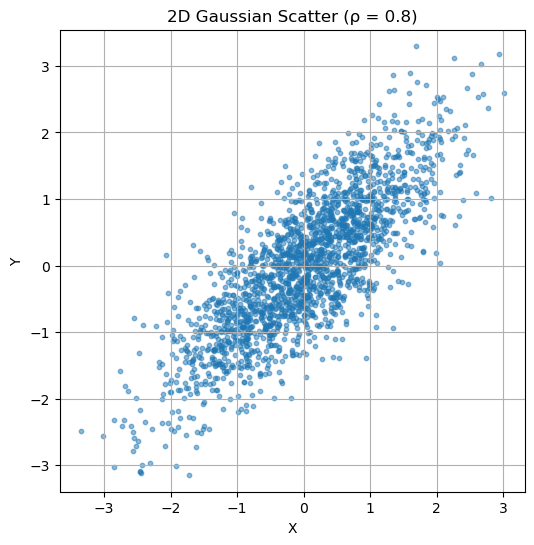

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Mean
mean = [0, 0]

# Standard deviations
sigma_x = 1
sigma_y = 1

# Correlation coefficient
rho = 0.8

# Correlation matrix
corr_matrix = np.array([
    [1, rho],
    [rho, 1]
])

# Convert to covariance matrix
std_matrix = np.array([
    [sigma_x, 0],
    [0, sigma_y]
])

cov_matrix = std_matrix @ corr_matrix @ std_matrix

# Generate points
n = 2000
data = np.random.multivariate_normal(mean, cov_matrix, n)
x, y = data[:, 0], data[:, 1]

# Plot (same clean style as before)
plt.figure(figsize=(6,6))
plt.scatter(x, y, alpha=0.5, s=10)

plt.title(f"2D Gaussian Scatter (ρ = {rho})")
plt.xlabel("X")
plt.ylabel("Y")

plt.axis('equal')
plt.grid(True)

plt.show()

Looking at the graph we can make tremendous assumptions : 
- we notice first that we must find a probability distribution over 2D space $\R^{2}$. 
- since points are scattered in a symmetrical way over the central point called the mean (to be found later) (skewness, or third moment = 0), meaning that gaussian assumption is valid here.
- Now we are left to find these gaussian parameters, a 2D gaussian is defined by : 
the mean $ \mu = \vec$

In [4]:
import numpy as np

# data = your (n,2) array
mu = np.mean(data, axis=0)
cov = np.cov(data.T)

print("Estimated mean:", mu)
print("Estimated covariance:\n", cov)

Estimated mean: [ 0.02332448 -0.00313353]
Estimated covariance:
 [[1.01597497 0.83088271]
 [0.83088271 1.05782522]]


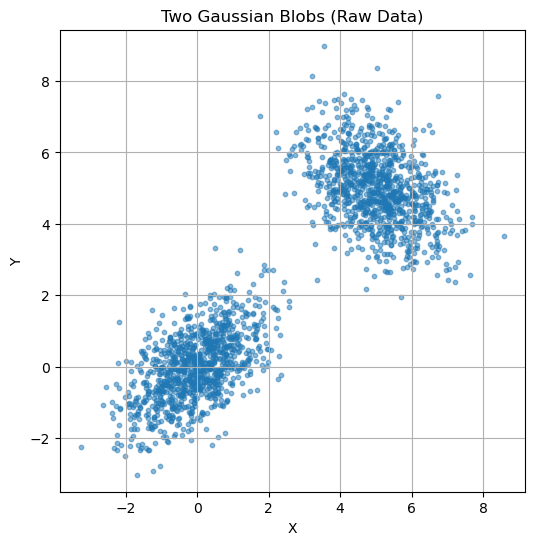

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# ----------------------------
# 1. Generate two Gaussian blobs
# ----------------------------
np.random.seed(42)

n = 1000

# Blob 1
mean1 = [0, 0]
cov1 = [[1, 0.6],
        [0.6, 1]]
data1 = np.random.multivariate_normal(mean1, cov1, n)

# Blob 2
mean2 = [5, 5]
cov2 = [[1, -0.4],
        [-0.4, 1]]
data2 = np.random.multivariate_normal(mean2, cov2, n)

# Combine data
data = np.vstack([data1, data2])

# ----------------------------
# 2. Plot raw data
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], s=10, alpha=0.5)
plt.title("Two Gaussian Blobs (Raw Data)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)

plt.show()



In [6]:

# ----------------------------
# 3. Fit Gaussian Mixture Model
# ----------------------------
gmm = GaussianMixture(n_components=2, random_state=42)
print(gmm)
gmm.fit(data)


# ----------------------------
# 4. Function to draw ellipses
# ----------------------------
def draw_ellipse(position, covariance, ax, **kwargs):
    from matplotlib.patches import Ellipse
    import numpy.linalg as la

    # Eigen decomposition
    vals, vecs = la.eigh(covariance)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    # Compute angle
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))

    # Width and height (2 std dev)
    width, height = 2 * np.sqrt(vals)

    ellipse = Ellipse(xy=position, width=width, height=height,
                      angle=theta, fill=False, **kwargs)
    ax.add_patch(ellipse)


# ----------------------------
# 5. Plot GMM approximation
# ----------------------------
plt.figure(figsize=(6,6))
plt.scatter(data[:,0], data[:,1], s=10, alpha=0.3)

ax = plt.gca()

# Plot each Gaussian component
for mean, cov in zip(gmm.means_, gmm.covariances_):
    draw_ellipse(mean, cov, ax, edgecolor='red', linewidth=2)

plt.title("GMM Approximation (2 Components)")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis('equal')
plt.grid(True)

plt.show()

GaussianMixture(n_components=2)


AttributeError: 'NoneType' object has no attribute 'split'